[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/elyssephillips/embryo_image_analysis/blob/main/pipelines/xenium/oocyte_transcript_counts_colab.ipynb)

# Oocyte transcript counting (Colab version)

Counts how many transcript dots (of one gene) fall inside the oocyte versus the
surrounding granulosa, non-granulosa, and background regions, for one hand-segmented
follicle.

When you run the parameters cell below, you'll be prompted to upload 3 files for the
same ROI (same view, same pixel size):
- a label mask TIFF, hand-edited in napari -- one class per pixel: background, oocyte, granulosa, non-granulosa
- a transcripts PNG for one gene, exported from Xenium Explorer (transparent background), named like `Transcripts_..._GENE.png`
- a cell layer PNG (the fluorescent image), named like `Images_....png`

**Steps:**
1. Load all three, confirm they're aligned
2. Measure Xenium's scale bar for a px-to-micron conversion, then draw our own from
   here on (cropping below removes Xenium's from view)
3. Pull the oocyte, granulosa, and non-granulosa masks directly out of the label mask
4. Crop to this follicle's bounding box (+ a margin) -- an ROI can hold more than one
   follicle, but only one gets segmented at a time, so anything else in frame must be
   excluded before it contaminates the "background" region
5. Find every transcript dot by color and classify it by region

This is the Colab-only version -- no local file path, no environment branching. For a
version that reads files from a local folder instead, see `oocyte_transcript_counts.ipynb`
in this same folder.

In [8]:
import numpy as np
import pandas as pd
import tifffile
from pathlib import Path
from PIL import Image
from scipy.ndimage import distance_transform_edt, binary_fill_holes, binary_closing
from skimage.measure import label, regionprops, find_contours
from skimage.morphology import disk
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.color import label2rgb
import matplotlib.pyplot as plt

%matplotlib inline

## Parameters

Per sample

In [9]:
# -- upload the 3 exported files for this ROI --
from google.colab import files

print("Select 3 files for this ROI: the label mask TIFF (e.g. cleaned_up_segmentation_mask_1.tiff), "
      "one gene's transcripts PNG (e.g. Transcripts_1_GDF9.png), and the cell layer PNG (e.g. Images_1.png).")
uploaded = files.upload()  # uploads land in /content, keeping their original filenames
INPUT_DIR = Path("/content")

label_mask_names = [name for name in uploaded if name.lower().endswith((".tif", ".tiff"))]
transcripts_names = [name for name in uploaded if name.startswith("Transcripts")]
cell_layer_names = [name for name in uploaded if name.startswith("Images")]
assert len(label_mask_names) == 1, f"expected exactly one label mask TIFF, got {label_mask_names}"
assert len(transcripts_names) == 1, f"expected exactly one transcripts PNG, got {transcripts_names}"
assert len(cell_layer_names) == 1, f"expected exactly one cell layer PNG, got {cell_layer_names}"

LABEL_MASK_FILE = INPUT_DIR / label_mask_names[0]
TRANSCRIPTS_FILE = INPUT_DIR / transcripts_names[0]
CELL_LAYER_FILE = INPUT_DIR / cell_layer_names[0]
OUTPUT_DIR = INPUT_DIR / "analysis"

sample_id = input("Sample ID for this ROI (used to name output files): ").strip()

# -- label mask values (set in napari when editing the segmentation) --
LABEL_GRANULOSA = 1       # granulosa cells, borders the oocyte
LABEL_NON_GRANULOSA = 2   # hand-segmented ring of non-granulosa cells just outside granulosa
LABEL_BACKGROUND = 3      # everything else (unsegmented)
LABEL_OOCYTE = 4

# -- transcript dot color -- auto-detected below from whatever's in TRANSCRIPTS_FILE --
TRANSCRIPT_DOT_RGB_OVERRIDE = None    # set this manually if auto-detection ever picks the wrong color
TRANSCRIPT_COLOR_TOLERANCE = 20

# -- geometry --
SCALE_BAR_UM = 50
PX_PER_UM_OVERRIDE = None     # set this manually if scale-bar auto-detection ever fails
BACKGROUND_MARGIN_UM = 15     # how far past the hand-segmented non-granulosa ring still
                               # counts as "background" for this follicle; shrink this if
                               # it starts to reach a neighboring follicle
WATERSHED_MIN_DISTANCE_PX = 2  # minimum peak separation when splitting touching transcript dots
CLOSING_RADIUS_UM = 3.0        # bridges small gaps in individual cell walls before filling
                               # granulosa/non-granulosa -- raise this if the mask panel
                               # below still shows notches biting into the ring

# -- plot colors: one consistent, colorblind-safe palette used in every figure below.
# Same hues always mean the same regions, everywhere in this notebook.
SURFACE = "#fcfcfb"       # chart background (near-white)
INK = "#0b0b0b"           # primary text/labels
INK_MUTED = "#898781"     # axis ticks, and the "background" region
GRID = "#e1e0d9"          # gridlines / spines
OOCYTE_COLOR = "#2a78d6"          # blue
GRANULOSA_COLOR = "#eb6834"       # orange
NON_GRANULOSA_COLOR = "#1baf7a"   # aqua

# The transcripts PNG has a transparent background -- shown on a light surface, faint
# content (like the dots) can disappear. Panels that display that raw layer directly
# use this dark background instead; panels showing an actual chart (bars, lines) or an
# opaque image (Cell_layer.png, the label mask, binary masks) keep using SURFACE/INK.
PNG_BG = "black"
PNG_INK = "white"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sample_id

Select 3 files for this ROI: the label mask TIFF (e.g. cleaned_up_segmentation_mask_1.tiff), one gene's transcripts PNG (e.g. Transcripts_1_GDF9.png), and the cell layer PNG (e.g. Images_1.png).


Saving cleaned_up_segmentation_mask_1.tiff to cleaned_up_segmentation_mask_1 (1).tiff
Saving Images_1.png to Images_1 (1).png
Saving Transcripts_1_AMH.png to Transcripts_1_AMH (1).png
Sample ID for this ROI (used to name output files): secondary stage 1


'secondary stage 1'

## Load images

The label mask loads as a 2D array of integer class IDs. The transcripts and cell layer
PNGs load as RGBA arrays: red, green, blue, and alpha (transparency) per pixel -- the
transcripts layer's background is fully transparent (alpha=0), drawn dots have nonzero
alpha.

label mask: 3024 x 1778 px, values [1, 2, 3, 4]
transcripts layer: 3024 x 1778 px
cell layer: 3024 x 1778 px
dimensions match, layers are aligned


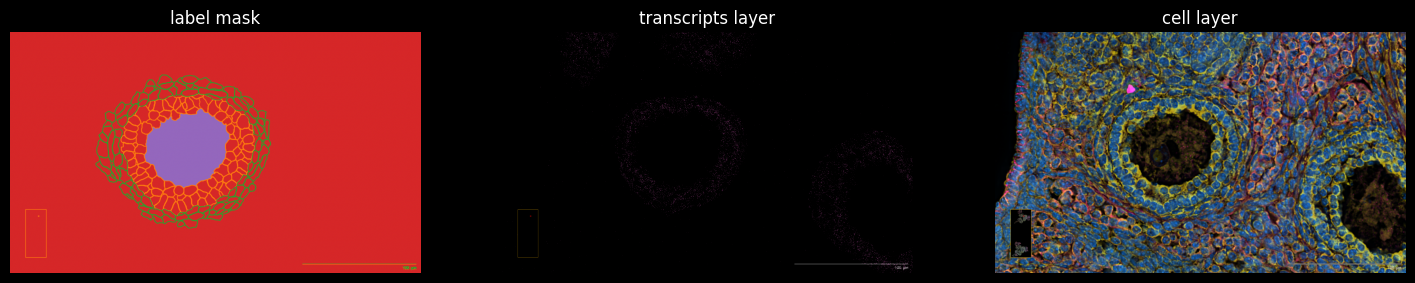

In [10]:
label_mask = tifffile.imread(LABEL_MASK_FILE)
transcripts_rgba = np.array(Image.open(TRANSCRIPTS_FILE).convert("RGBA"))
cell_layer_rgba = np.array(Image.open(CELL_LAYER_FILE).convert("RGBA"))

print(f"label mask: {label_mask.shape[1]} x {label_mask.shape[0]} px, values {sorted(np.unique(label_mask).tolist())}")
print(f"transcripts layer: {transcripts_rgba.shape[1]} x {transcripts_rgba.shape[0]} px")
print(f"cell layer: {cell_layer_rgba.shape[1]} x {cell_layer_rgba.shape[0]} px")

assert label_mask.shape[:2] == transcripts_rgba.shape[:2] == cell_layer_rgba.shape[:2], \
    "label mask, transcripts layer, and cell layer have different dimensions -- exports must be aligned."
print("dimensions match, layers are aligned")

# Visual check: does this look like what you expect?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(PNG_BG)
for ax in axes:
    ax.set_facecolor(PNG_BG)
axes[0].imshow(label_mask, cmap="tab10", vmin=0, vmax=9)
axes[0].set_title("label mask", color=PNG_INK)
axes[0].axis("off")
axes[1].imshow(transcripts_rgba)
axes[1].set_title("transcripts layer", color=PNG_INK)
axes[1].axis("off")
axes[2].imshow(cell_layer_rgba)
axes[2].set_title("cell layer", color=PNG_INK)
axes[2].axis("off")
plt.show()

## Detect the transcript dot color

Xenium Explorer's exports always include the same black border, gray scale bar, and
amber marker regardless of gene -- excluding those, the most common remaining opaque
color is this gene's transcript dot color.

In [11]:
def find_transcript_dot_color(rgba, exclude_rgbs=((0, 0, 0), (240, 240, 240), (255, 190, 0)),
                               exclude_tolerance=15):
    red = rgba[..., 0].astype(int)
    green = rgba[..., 1].astype(int)
    blue = rgba[..., 2].astype(int)
    alpha = rgba[..., 3]

    is_chrome = np.zeros(alpha.shape, dtype=bool)
    for r, g, b in exclude_rgbs:
        is_chrome |= (
            (np.abs(red - r) <= exclude_tolerance)
            & (np.abs(green - g) <= exclude_tolerance)
            & (np.abs(blue - b) <= exclude_tolerance)
        )
    candidates = rgba[(alpha == 255) & ~is_chrome][:, :3]
    if len(candidates) == 0:
        raise RuntimeError("Could not auto-detect transcript dot color -- set TRANSCRIPT_DOT_RGB_OVERRIDE above.")
    colors, counts = np.unique(candidates, axis=0, return_counts=True)
    return tuple(int(c) for c in colors[counts.argmax()])


TRANSCRIPT_DOT_RGB = TRANSCRIPT_DOT_RGB_OVERRIDE or find_transcript_dot_color(transcripts_rgba)
print(f"transcript dot color: {TRANSCRIPT_DOT_RGB}")

transcript dot color: (255, 106, 219)


## Find the scale bar, and set up our own

Xenium Explorer includes a scale bar, which we use to convert pixels to real units.
Everything below crops in on just this follicle, though, which cuts Xenium's own scale
bar (drawn in a corner of the full export) out of view -- so `draw_scale_bar` below
draws a small one of our own on every cropped figure from here on.

In [12]:
def find_px_per_um(rgba, scale_bar_um, search_right_fraction=0.5):
    red = rgba[..., 0].astype(int)
    green = rgba[..., 1].astype(int)
    blue = rgba[..., 2].astype(int)
    alpha = rgba[..., 3]

    width = rgba.shape[1]
    is_scale_bar_pixel = (
        (alpha == 255)
        & (np.abs(red - 240) < 10) & (np.abs(green - 240) < 10) & (np.abs(blue - 240) < 10)
    )
    is_scale_bar_pixel[:, : int(width * search_right_fraction)] = False

    _, xs = np.where(is_scale_bar_pixel)
    if xs.size == 0:
        raise RuntimeError("Could not auto-detect scale bar -- set PX_PER_UM_OVERRIDE above.")
    scale_bar_length_px = xs.max() - xs.min()
    return scale_bar_length_px / scale_bar_um


px_per_um = PX_PER_UM_OVERRIDE or find_px_per_um(transcripts_rgba, SCALE_BAR_UM)
print(f"scale: {px_per_um:.3f} px/um")


scale: 16.760 px/um


In [13]:
def draw_scale_bar(ax, px_per_um, um=SCALE_BAR_UM, color=INK):
    """Draw a simple scale bar in the lower-right corner of an image axes."""
    bar_px = um * px_per_um
    x1 = max(ax.get_xlim()) - bar_px * 0.15
    x0 = x1 - bar_px
    y = max(ax.get_ylim()) - bar_px * 0.15
    ax.plot([x0, x1], [y, y], color=color, linewidth=3, solid_capstyle="butt")
    ax.text((x0 + x1) / 2, y - bar_px * 0.08, f"{um} um", color=color,
            fontsize=9, ha="center", va="bottom")

## Pull masks from the label file

Oocyte is already a filled, hand-corrected region -- just "pixels equal to its label's
ID." Granulosa and non-granulosa are drawn as individual cell outlines instead (a
honeycomb mesh, not filled interiors): each keeps only its largest connected region
first (drops stray mislabeled pixels elsewhere in the frame), then gets a small
`binary_closing` to bridge cracks in individual cell walls. `binary_fill_holes` then turns every
enclosed cell into a filled area, and whatever's actually a different region gets
subtracted back out (granulosa's fill also encloses the oocyte's hole; non-granulosa's
fill encloses oocyte + granulosa too).

granulosa: 404,024 px (1438.3 um^2)
non-granulosa: 415,645 px (1479.7 um^2)
oocyte mask: 248,656 px (885.2 um^2)


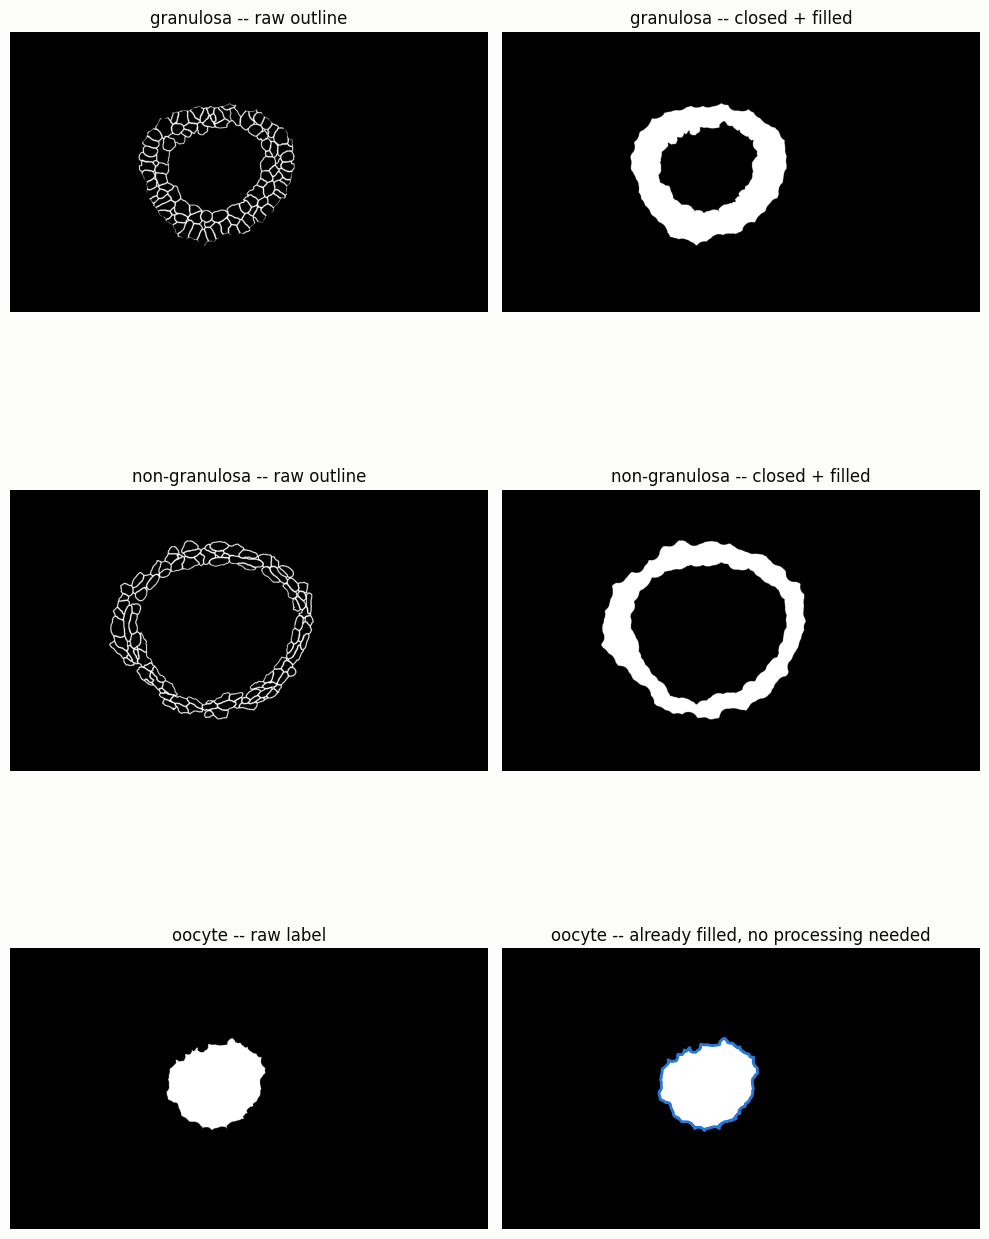

In [14]:
def largest_component(mask):
    """Keep only the largest connected blob -- drops stray mislabeled pixels elsewhere in the frame."""
    labeled_regions = label(mask)
    if labeled_regions.max() == 0:
        return mask
    largest = max(regionprops(labeled_regions), key=lambda region: region.area).label
    return labeled_regions == largest


oocyte_mask = largest_component(label_mask == LABEL_OOCYTE)

closing_radius_px = round(CLOSING_RADIUS_UM * px_per_um)
granulosa_outline = largest_component(label_mask == LABEL_GRANULOSA)
non_granulosa_outline = largest_component(label_mask == LABEL_NON_GRANULOSA)
granulosa_closed = binary_closing(granulosa_outline, structure=disk(closing_radius_px))
non_granulosa_closed = binary_closing(non_granulosa_outline, structure=disk(closing_radius_px))
granulosa_mask = binary_fill_holes(granulosa_closed) & ~oocyte_mask
non_granulosa_mask = binary_fill_holes(non_granulosa_closed) & ~oocyte_mask & ~granulosa_mask

oocyte_area_um2 = oocyte_mask.sum() / (px_per_um ** 2)
granulosa_area_um2 = granulosa_mask.sum() / (px_per_um ** 2)
non_granulosa_area_um2 = non_granulosa_mask.sum() / (px_per_um ** 2)
print(f"granulosa: {granulosa_mask.sum():,} px ({granulosa_area_um2:.1f} um^2)")
print(f"non-granulosa: {non_granulosa_mask.sum():,} px ({non_granulosa_area_um2:.1f} um^2)")
print(f"oocyte mask: {oocyte_mask.sum():,} px ({oocyte_area_um2:.1f} um^2)")

oocyte_outlines = find_contours(oocyte_mask.astype(float), 0.5)
oocyte_raw = largest_component(label_mask == LABEL_OOCYTE)

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
fig.patch.set_facecolor(SURFACE)
for row in axes:
    for ax in row:
        ax.set_facecolor(SURFACE)

axes[0, 0].imshow(granulosa_outline, cmap="gray")
axes[0, 0].set_title("granulosa -- raw outline", color=INK)
axes[0, 0].axis("off")
axes[0, 1].imshow(granulosa_mask, cmap="gray")
axes[0, 1].set_title("granulosa -- closed + filled", color=INK)
axes[0, 1].axis("off")

axes[1, 0].imshow(non_granulosa_outline, cmap="gray")
axes[1, 0].set_title("non-granulosa -- raw outline", color=INK)
axes[1, 0].axis("off")
axes[1, 1].imshow(non_granulosa_mask, cmap="gray")
axes[1, 1].set_title("non-granulosa -- closed + filled", color=INK)
axes[1, 1].axis("off")

axes[2, 0].imshow(oocyte_raw, cmap="gray")
axes[2, 0].set_title("oocyte -- raw label", color=INK)
axes[2, 0].axis("off")
axes[2, 1].imshow(oocyte_mask, cmap="gray")
for outline in oocyte_outlines:
    axes[2, 1].plot(outline[:, 1], outline[:, 0], color=OOCYTE_COLOR, linewidth=2)
axes[2, 1].set_title("oocyte -- already filled, no processing needed", color=INK)
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

## Crop to this follicle's bounding box

An ROI can contain more than one follicle, but only one gets hand-segmented at a time --
anything else in the frame (a second follicle, stray tissue) would otherwise get
miscounted as "background" signal for this one. Take the bounding box of the segmented
layers (oocyte + granulosa + non-granulosa), pad it by `BACKGROUND_MARGIN_UM` to leave
room for a meaningful background comparison region, and crop everything else out.

**Check the box in the figure below before moving on** -- if it reaches into a
neighboring follicle or other tissue you don't want counted, lower
`BACKGROUND_MARGIN_UM` above and re-run from there.

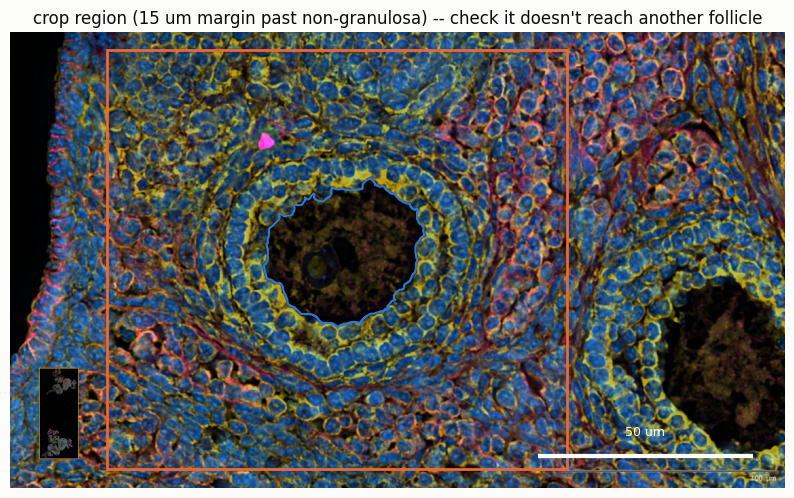

cropped to rows 68:1702, cols 378:2173 (1795 x 1634 px)


In [15]:
segmented_mask = granulosa_mask | non_granulosa_mask | oocyte_mask
rows, cols = np.where(segmented_mask)
margin_px = round(BACKGROUND_MARGIN_UM * px_per_um)

row_min = max(0, rows.min() - margin_px)
row_max = min(label_mask.shape[0], rows.max() + margin_px + 1)
col_min = max(0, cols.min() - margin_px)
col_max = min(label_mask.shape[1], cols.max() + margin_px + 1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SURFACE)
ax.imshow(cell_layer_rgba)
for outline in oocyte_outlines:
    ax.plot(outline[:, 1], outline[:, 0], color=OOCYTE_COLOR, linewidth=1.5)
rect = plt.Rectangle((col_min, row_min), col_max - col_min, row_max - row_min,
                      fill=False, edgecolor=GRANULOSA_COLOR, linewidth=2)
ax.add_patch(rect)
draw_scale_bar(ax, px_per_um, color=PNG_INK)
ax.set_title(f"crop region ({BACKGROUND_MARGIN_UM} um margin past non-granulosa) -- "
             "check it doesn't reach another follicle", color=INK)
ax.axis("off")
plt.show()

row_slice = slice(row_min, row_max)
col_slice = slice(col_min, col_max)
label_mask = label_mask[row_slice, col_slice]
transcripts_rgba = transcripts_rgba[row_slice, col_slice]
cell_layer_rgba = cell_layer_rgba[row_slice, col_slice]
granulosa_mask = granulosa_mask[row_slice, col_slice]
non_granulosa_mask = non_granulosa_mask[row_slice, col_slice]
oocyte_mask = oocyte_mask[row_slice, col_slice]
oocyte_outlines = find_contours(oocyte_mask.astype(float), 0.5)

print(f"cropped to rows {row_min}:{row_max}, cols {col_min}:{col_max} "
      f"({label_mask.shape[1]} x {label_mask.shape[0]} px)")

## Find transcript dots

Each transcript is a small dot in a color specific to this gene (`TRANSCRIPT_DOT_RGB`
above -- check the PNG and update it if dots aren't detected). Dots that touch or
overlap would otherwise merge into one connected blob and get undercounted. A watershed split, seeded by local peaks in the
distance transform, separates touching dots before each blob's centroid becomes one
transcript's position.

transcript dots detected: 6757


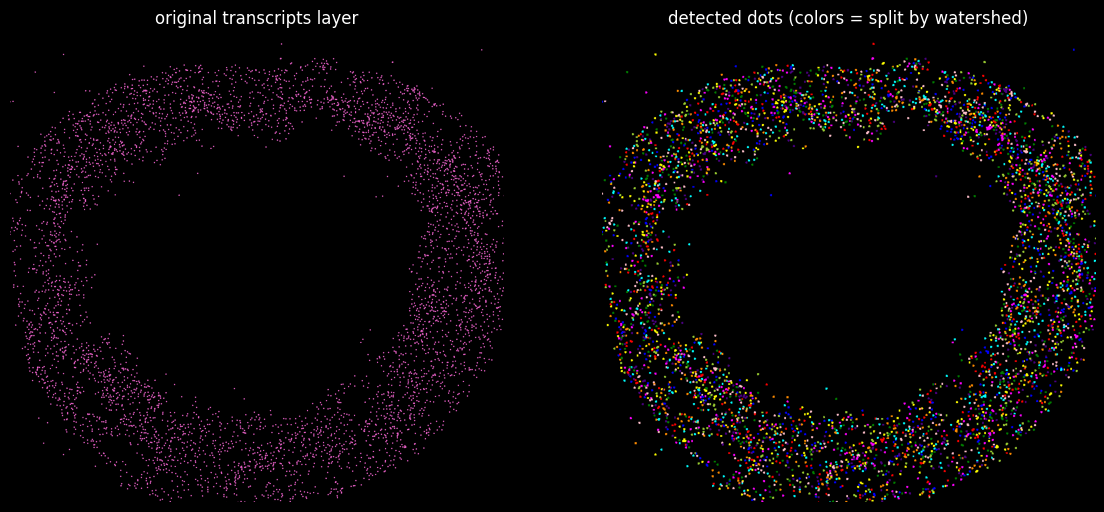

In [16]:
red = transcripts_rgba[..., 0].astype(int)
green = transcripts_rgba[..., 1].astype(int)
blue = transcripts_rgba[..., 2].astype(int)
alpha = transcripts_rgba[..., 3]

dot_mask = (
    (alpha > 0)
    & (np.abs(red - TRANSCRIPT_DOT_RGB[0]) <= TRANSCRIPT_COLOR_TOLERANCE)
    & (np.abs(green - TRANSCRIPT_DOT_RGB[1]) <= TRANSCRIPT_COLOR_TOLERANCE)
    & (np.abs(blue - TRANSCRIPT_DOT_RGB[2]) <= TRANSCRIPT_COLOR_TOLERANCE)
)

# Distance-transform peaks as watershed seeds -- splits touching/overlapping dots
# instead of counting them as one blob.
distance = distance_transform_edt(dot_mask)
peak_coords = peak_local_max(distance, min_distance=WATERSHED_MIN_DISTANCE_PX, labels=dot_mask)
peak_mask = np.zeros(distance.shape, dtype=bool)
peak_mask[tuple(peak_coords.T)] = True
markers = label(peak_mask)
labeled_dots = watershed(-distance, markers, mask=dot_mask)
dot_positions = np.array([region.centroid for region in regionprops(labeled_dots)])  # (row, col) per dot

print(f"transcript dots detected: {len(dot_positions)}")

# crop to a window around the oocyte (where the dots we care about are) before showing.
oocyte_ys, oocyte_xs = np.where(oocyte_mask)
pad = 150
y_slice = slice(max(0, oocyte_ys.min() - pad), oocyte_ys.max() + pad)
x_slice = slice(max(0, oocyte_xs.min() - pad), oocyte_xs.max() + pad)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(PNG_BG)
for ax in axes:
    ax.set_facecolor(PNG_BG)
axes[0].imshow(transcripts_rgba[y_slice, x_slice])
axes[0].set_title("original transcripts layer", color=PNG_INK)
axes[0].axis("off")
axes[1].imshow(label2rgb(labeled_dots[y_slice, x_slice], bg_label=0, bg_color=(0, 0, 0)))
axes[1].set_title("detected dots (colors = split by watershed)", color=PNG_INK)
axes[1].axis("off")
plt.show()

## Classify each dot as inside or outside the oocyte

Since `dot_positions` and `oocyte_mask` are both already in the same pixel grid, directly look up its positioning for classification

In [17]:
dot_rows = np.clip(dot_positions[:, 0].round().astype(int), 0, oocyte_mask.shape[0] - 1)
dot_cols = np.clip(dot_positions[:, 1].round().astype(int), 0, oocyte_mask.shape[1] - 1)
dot_is_in_oocyte = oocyte_mask[dot_rows, dot_cols]

print(f"transcript dots inside oocyte: {int(dot_is_in_oocyte.sum())} / {len(dot_positions)}")


transcript dots inside oocyte: 44 / 6757


## Print overlays, normalize by area

Density normalizes the in-oocyte count by the oocyte's area, since a bigger oocyte will contain more transcripts even at the same expression level.


        sample_id  transcripts_total_detected  transcripts_in_oocyte  oocyte_area_px  oocyte_area_um2  transcript_density_per_um2  px_per_um
secondary stage 1                        6757                     44          248656       885.219382                    0.049705      16.76


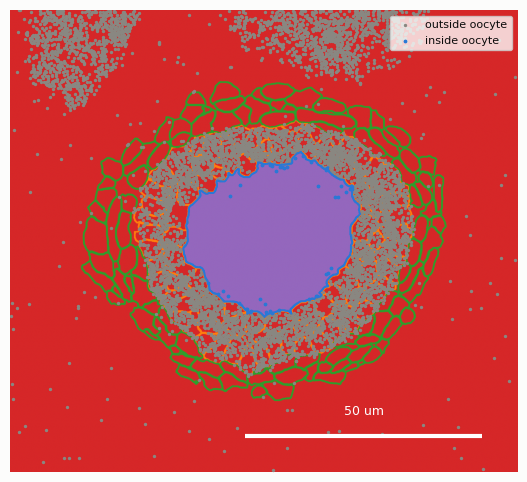

In [18]:
oocyte_area_px = int(oocyte_mask.sum())
oocyte_area_um2 = oocyte_area_px / (px_per_um ** 2)
transcripts_in_oocyte = int(dot_is_in_oocyte.sum())
density_per_um2 = transcripts_in_oocyte / oocyte_area_um2 if oocyte_area_um2 else float("nan")

result = {
    "sample_id": sample_id,
    "transcripts_total_detected": len(dot_positions),
    "transcripts_in_oocyte": transcripts_in_oocyte,
    "oocyte_area_px": oocyte_area_px,
    "oocyte_area_um2": oocyte_area_um2,
    "transcript_density_per_um2": density_per_um2,
    "px_per_um": px_per_um,
}
result_df = pd.DataFrame([result])
print(result_df.to_string(index=False))

# Visual QC
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.imshow(label_mask, cmap="tab10", vmin=0, vmax=9)
for outline in find_contours(oocyte_mask.astype(float), 0.5):
    ax.plot(outline[:, 1], outline[:, 0], color=OOCYTE_COLOR, linewidth=1.5)
if len(dot_positions):
    outside = dot_positions[~dot_is_in_oocyte]
    inside = dot_positions[dot_is_in_oocyte]
    ax.scatter(outside[:, 1], outside[:, 0], s=2, color=INK_MUTED, label="outside oocyte")
    ax.scatter(inside[:, 1], inside[:, 0], s=3, color=OOCYTE_COLOR, label="inside oocyte")
ax.legend(loc="upper right", fontsize=8, facecolor=SURFACE, labelcolor=INK)
draw_scale_bar(ax, px_per_um, color=PNG_INK)
ax.axis("off")
plt.show()

fig.savefig(OUTPUT_DIR / f"{sample_id}_qc_overlay.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)

In [ ]:
result_df.to_csv(OUTPUT_DIR / f"{sample_id}_oocyte_transcript_counts.csv", index=False)
print(f"saved results to {OUTPUT_DIR / f'{sample_id}_oocyte_transcript_counts.csv'}")


## Compare transcript levels between granulosa, non-granulosa, and background

Granulosa and non-granulosa areas come straight out of the label mask. "Background" is whatever's left inside the cropped
bounding box -- a real, bounded area, not an open-ended count.

       region  transcripts    area_um2  density_per_um2
       oocyte           44  885.219382         0.049705
    granulosa         4451 1438.331976         3.094557
non_granulosa          176 1479.702924         0.118943
   background         2086 6638.379965         0.314233
saved /content/analysis/secondary stage 1_density_by_region.csv


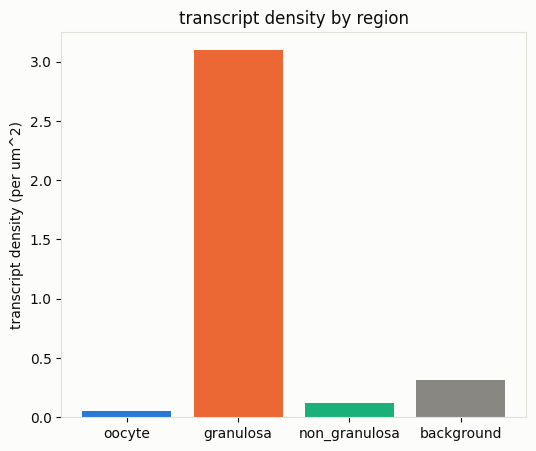

saved /content/analysis/secondary stage 1_density_by_region.png


In [19]:
dot_in_granulosa = granulosa_mask[dot_rows, dot_cols] & ~dot_is_in_oocyte
dot_in_non_granulosa = non_granulosa_mask[dot_rows, dot_cols] & ~dot_is_in_oocyte & ~dot_in_granulosa
dot_in_background = ~dot_is_in_oocyte & ~dot_in_granulosa & ~dot_in_non_granulosa

# Now that the frame is cropped to just this follicle (+ margin), "background" is a
# bounded region and has a real area, not just a leftover count.
background_mask = ~(oocyte_mask | granulosa_mask | non_granulosa_mask)
background_area_um2 = background_mask.sum() / (px_per_um ** 2)

region_counts = {
    "oocyte": int(dot_is_in_oocyte.sum()),
    "granulosa": int(dot_in_granulosa.sum()),
    "non_granulosa": int(dot_in_non_granulosa.sum()),
    "background": int(dot_in_background.sum()),
}
region_areas_um2 = {
    "oocyte": oocyte_area_um2,
    "granulosa": granulosa_area_um2,
    "non_granulosa": non_granulosa_area_um2,
    "background": background_area_um2,
}

region_df = pd.DataFrame({
    "region": list(region_counts.keys()),
    "transcripts": list(region_counts.values()),
})
region_df["area_um2"] = region_df["region"].map(region_areas_um2)
region_df["density_per_um2"] = region_df["transcripts"] / region_df["area_um2"]
print(region_df.to_string(index=False))

region_df.to_csv(OUTPUT_DIR / f"{sample_id}_density_by_region.csv", index=False)
print(f"saved {OUTPUT_DIR / f'{sample_id}_density_by_region.csv'}")

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(region_df["region"], region_df["density_per_um2"],
               color=[OOCYTE_COLOR, GRANULOSA_COLOR, NON_GRANULOSA_COLOR, INK_MUTED])
ax.set_ylabel("transcript density (per um^2)", color=INK)
ax.set_title("transcript density by region", color=INK)
ax.tick_params(colors=INK)
for spine in ax.spines.values():
    spine.set_color(GRID)
plt.show()

fig.savefig(OUTPUT_DIR / f"{sample_id}_density_by_region.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
print(f"saved {OUTPUT_DIR / f'{sample_id}_density_by_region.png'}")

## Transcript density vs distance from the oocyte boundary

`distance_transform_edt` gives, for every pixel outside the oocyte, its distance to
the nearest oocyte pixel (and 0 for pixels inside the oocyte). Looking each dot up in
that distance map gives a per-dot "how far outside the oocyte is this transcript"
value, in microns. Binning dots by that distance and dividing by how much image area
actually exists at each distance (a thin shell has less area than a thick one) gives a
density curve instead of a raw count curve.

Dashed lines mark roughly where granulosa ends and non-granulosa ends, using the 90th
percentile distance of dots actually assigned to each region above (a robust stand-in
for "the outer edge", since neither region is perfectly circular).

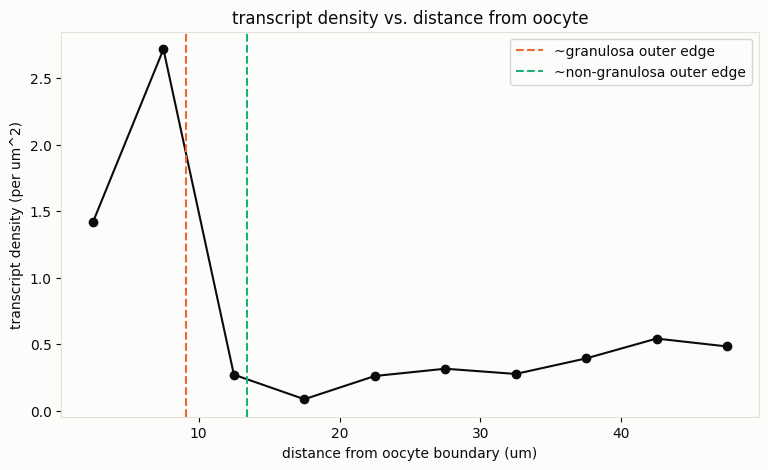

In [20]:
distance_px = distance_transform_edt(~oocyte_mask)
distance_um = distance_px / px_per_um
dot_distance_um = distance_um[dot_rows, dot_cols]

bin_width_um = 5
max_distance_um = np.percentile(dot_distance_um, 99)
bin_edges = np.arange(0, max_distance_um + bin_width_um, bin_width_um)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

counts, _ = np.histogram(dot_distance_um, bins=bin_edges)
shell_area_um2 = np.array([
    ((distance_um >= lo) & (distance_um < hi)).sum() / (px_per_um ** 2)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:])
])
density = np.divide(counts, shell_area_um2, out=np.zeros_like(counts, dtype=float), where=shell_area_um2 > 0)

granulosa_edge_um = np.percentile(dot_distance_um[dot_in_granulosa], 90) if dot_in_granulosa.any() else None
non_granulosa_edge_um = np.percentile(dot_distance_um[dot_in_non_granulosa], 90) if dot_in_non_granulosa.any() else None

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(bin_centers, density, marker="o", color=INK)
if granulosa_edge_um is not None:
    ax.axvline(granulosa_edge_um, color=GRANULOSA_COLOR, linestyle="--", label="~granulosa outer edge")
if non_granulosa_edge_um is not None:
    ax.axvline(non_granulosa_edge_um, color=NON_GRANULOSA_COLOR, linestyle="--", label="~non-granulosa outer edge")
ax.set_xlabel("distance from oocyte boundary (um)", color=INK)
ax.set_ylabel("transcript density (per um^2)", color=INK)
ax.set_title("transcript density vs. distance from oocyte", color=INK)
ax.tick_params(colors=INK)
for spine in ax.spines.values():
    spine.set_color(GRID)
ax.legend(facecolor=SURFACE, labelcolor=INK)
plt.show()

fig.savefig(OUTPUT_DIR / f"{sample_id}_density_vs_distance.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)

## Overlay and save


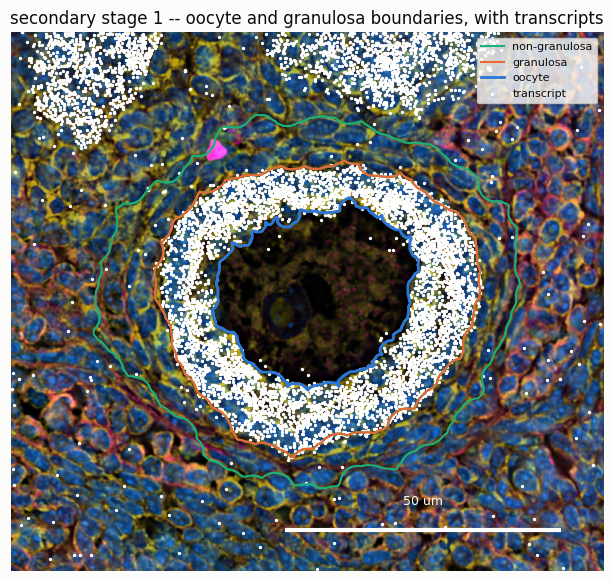

saved /content/analysis/secondary stage 1_overlay_on_cell_layer.png


In [21]:
granulosa_outlines = find_contours(granulosa_mask.astype(float), 0.5)
non_granulosa_outlines = find_contours(non_granulosa_mask.astype(float), 0.5)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(SURFACE)
ax.imshow(cell_layer_rgba)


for outline in non_granulosa_outlines:
    ax.plot(outline[:, 1], outline[:, 0], color=NON_GRANULOSA_COLOR, linewidth=1.5, label="non-granulosa")
for outline in granulosa_outlines:
    ax.plot(outline[:, 1], outline[:, 0], color=GRANULOSA_COLOR, linewidth=1.5, label="granulosa")
for outline in oocyte_outlines:
    ax.plot(outline[:, 1], outline[:, 0], color=OOCYTE_COLOR, linewidth=2, label="oocyte")
ax.scatter(dot_positions[:, 1], dot_positions[:, 0], s=2, color=PNG_INK, label="transcript")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # each boundary can be several line segments -- keep one entry per label
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8, facecolor=SURFACE, labelcolor=INK)
draw_scale_bar(ax, px_per_um, color=PNG_INK)
ax.set_title(f"{sample_id} -- oocyte and granulosa boundaries, with transcripts", color=INK)
ax.axis("off")
plt.show()

fig.savefig(OUTPUT_DIR / f"{sample_id}_overlay_on_cell_layer.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
print(f"saved {OUTPUT_DIR / f'{sample_id}_overlay_on_cell_layer.png'}")

## Download results

`/content` isn't persistent -- it's wiped when the runtime disconnects. This zips up everything in `OUTPUT_DIR` and downloads it to your computer.

In [22]:
import shutil
from google.colab import files as colab_files
archive_path = shutil.make_archive(f"/content/{sample_id}_results", "zip", OUTPUT_DIR)
colab_files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>